<a href="https://colab.research.google.com/github/jagadambika13/code/blob/main/ThamattoorHarigovind_Jagadambika_4242891_BusinessIntelligence(DLMDSEBA02)_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1. Loading and Reading data**

Loading the Telco Customer Churn dataset and displaying the first few rows to confirm it is loaded correctly.



In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load dataset

df = pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv")

print('Dataset loaded successfully.')
print(f'Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}')
df.head()

Dataset loaded successfully.
Rows: 7,043  |  Columns: 21


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# **2. Checking Shape and Data Types**

Checking the dimensions of the dataset and the data type of every variable.

In [4]:
print('Dataset Shape')
print(f'Rows: {df.shape[0]}  |  Columns: {df.shape[1]}')

print('\n Data Types')
print(df.dtypes)

print('\n Column List')
print(list(df.columns))

Dataset Shape
Rows: 7043  |  Columns: 21

 Data Types
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

 Column List
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


# **3. Checking and Handling Null Values**

Identifying any missing or null values in the dataset and removing or imputing them so the data is clean for analysis.

In [5]:
# TotalCharges is stored as string — convert to numeric (blanks become NaN)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print('Null Values Before Cleaning')
print(df.isnull().sum())

# Fill NaN in TotalCharges with median
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

print('\n Null Values After Cleaning')
print(df.isnull().sum())
print('\nDataset is clean. No null values remain.')

Null Values Before Cleaning
customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

 Null Values After Cleaning
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn  

# **4. Descriptive Analysis**

Generating summary statistics for all numerical variables to understand the distribution, central tendency, and spreading of the data.

In [6]:
print('Descriptive Statistics (Numerical Variables)')
print(df.describe().round(2).T)
print('\n Churn Distribution')
print(df['Churn'].value_counts())
print(f"\nChurn Rate: {df['Churn'].value_counts(normalize=True)['Yes']*100:.1f}%")

print('\n Categorical Variable Summaries')
cat_cols = ['Contract', 'InternetService', 'PaymentMethod', 'gender']
for col in cat_cols:
    print(f'\n{col}:')
    print(df[col].value_counts())

Descriptive Statistics (Numerical Variables)
                 count     mean      std    min     25%      50%      75%  \
SeniorCitizen   7043.0     0.16     0.37   0.00    0.00     0.00     0.00   
tenure          7043.0    32.37    24.56   0.00    9.00    29.00    55.00   
MonthlyCharges  7043.0    64.76    30.09  18.25   35.50    70.35    89.85   
TotalCharges    7043.0  2281.92  2265.27  18.80  402.22  1397.48  3786.60   

                    max  
SeniorCitizen      1.00  
tenure            72.00  
MonthlyCharges   118.75  
TotalCharges    8684.80  

 Churn Distribution
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn Rate: 26.5%

 Categorical Variable Summaries

Contract:
Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

InternetService:
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

PaymentMethod:
PaymentMethod
Electronic check             2365
Mailed chec

# **5. Correlation Analysis**

Computing the correlation matrix for numerical features to identify relationships between variables and their association with churn.

Correlation Matrix
                SeniorCitizen  tenure  MonthlyCharges  TotalCharges  \
SeniorCitizen           1.000   0.017           0.220         0.103   
tenure                  0.017   1.000           0.248         0.825   
MonthlyCharges          0.220   0.248           1.000         0.651   
TotalCharges            0.103   0.825           0.651         1.000   
Churn_Binary            0.151  -0.352           0.193        -0.199   

                Churn_Binary  
SeniorCitizen          0.151  
tenure                -0.352  
MonthlyCharges         0.193  
TotalCharges          -0.199  
Churn_Binary           1.000  

 Correlation with Churn
Churn_Binary      1.000
MonthlyCharges    0.193
SeniorCitizen     0.151
TotalCharges     -0.199
tenure           -0.352
Name: Churn_Binary, dtype: float64


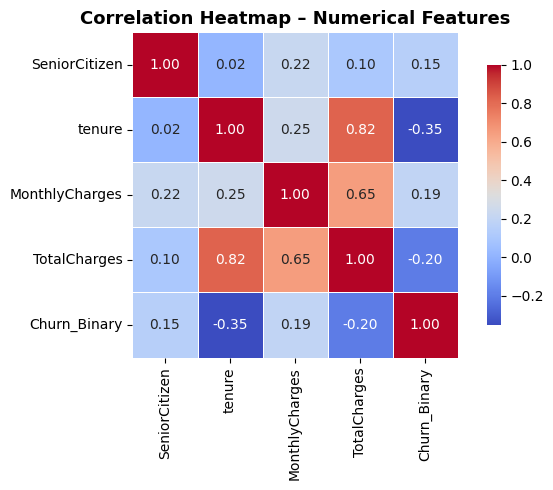

In [7]:
# Encode Churn as binary for correlation
df['Churn_Binary'] = (df['Churn'] == 'Yes').astype(int)

num_df = df[['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_Binary']]

corr_matrix = num_df.corr().round(3)

print('Correlation Matrix')
print(corr_matrix)

print('\n Correlation with Churn')
print(corr_matrix['Churn_Binary'].sort_values(ascending=False))

plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True, cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap – Numerical Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# **6. Time Series Analysis**

This dataset does not contain a date or timestamp column, so a traditional time series analysis is not applicable. Instead, tenure (months with the company) is used as a time proxy to analyse how churn behaviour changes as customer lifetime increases.

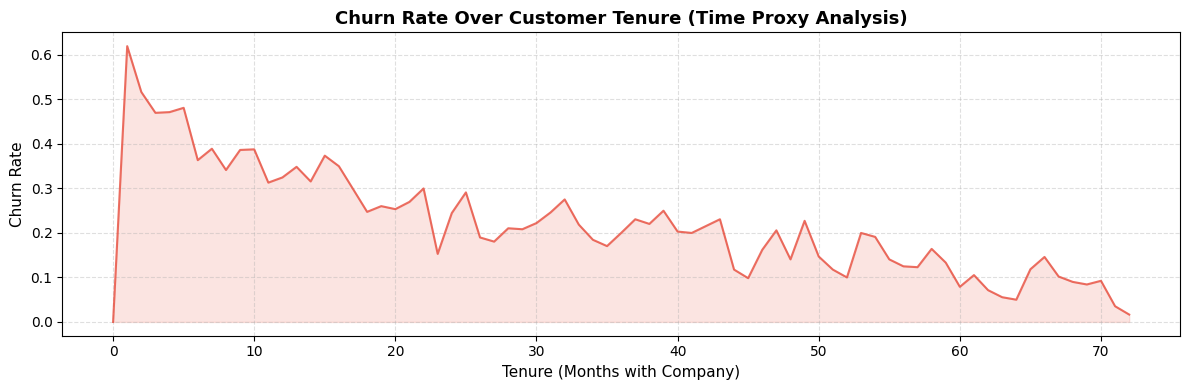

Note: No date column exists in this dataset.
Tenure is used as a time proxy — higher tenure indicates longer customer lifetime.

Average tenure: 32.4 months
Churn rate for tenure < 12 months: 48.3%
Churn rate for tenure > 48 months: 9.5%


In [8]:
# Group by tenure and compute churn rate per month
tenure_churn = df.groupby('tenure')['Churn_Binary'].mean().reset_index()
tenure_churn.columns = ['Tenure_Months', 'Churn_Rate']

plt.figure(figsize=(12, 4))
plt.plot(tenure_churn['Tenure_Months'], tenure_churn['Churn_Rate'],
         color='#e74c3c', linewidth=1.5, alpha=0.8)
plt.fill_between(tenure_churn['Tenure_Months'], tenure_churn['Churn_Rate'],
                 alpha=0.15, color='#e74c3c')
plt.xlabel('Tenure (Months with Company)', fontsize=11)
plt.ylabel('Churn Rate', fontsize=11)
plt.title('Churn Rate Over Customer Tenure (Time Proxy Analysis)', fontsize=13, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

print('Note: No date column exists in this dataset.')
print('Tenure is used as a time proxy — higher tenure indicates longer customer lifetime.')
print(f"\nAverage tenure: {df['tenure'].mean():.1f} months")
print(f"Churn rate for tenure < 12 months: {df[df['tenure']<12]['Churn_Binary'].mean()*100:.1f}%")
print(f"Churn rate for tenure > 48 months: {df[df['tenure']>48]['Churn_Binary'].mean()*100:.1f}%")

# **7. Data Visualisations (5 Charts)**

Five separate visualisations are created to explore the most important patterns in the dataset related to customer churn.

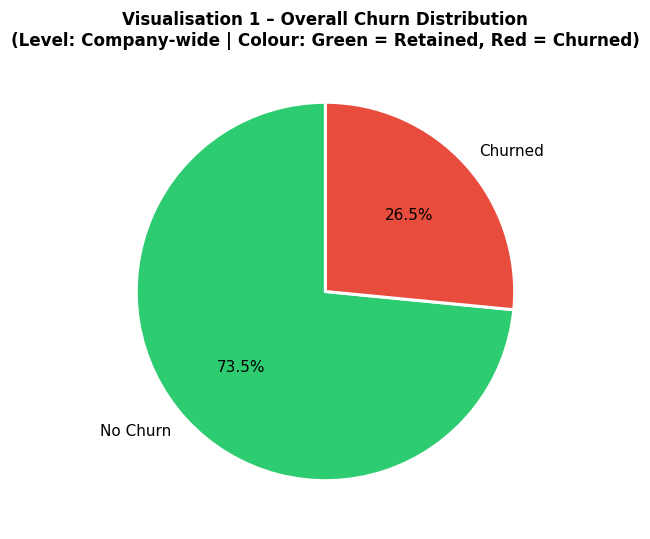

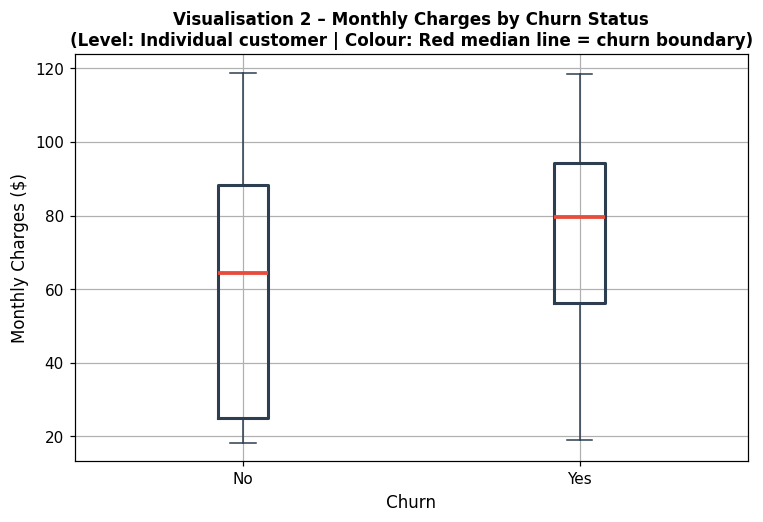

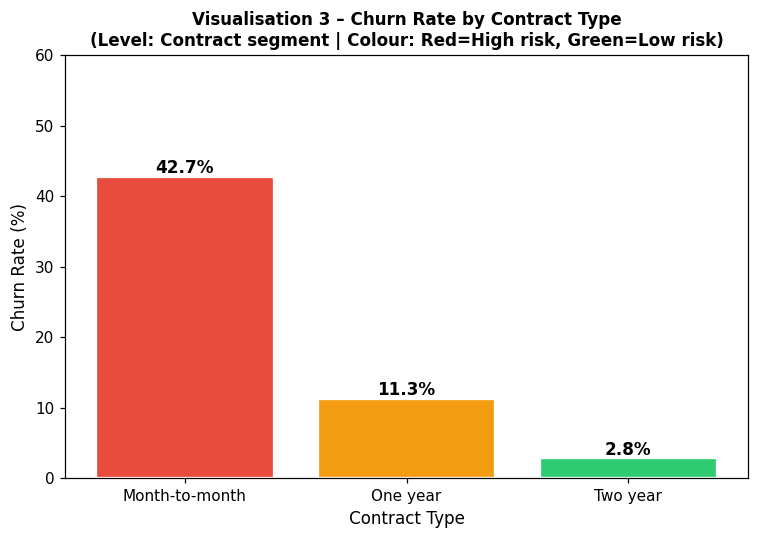

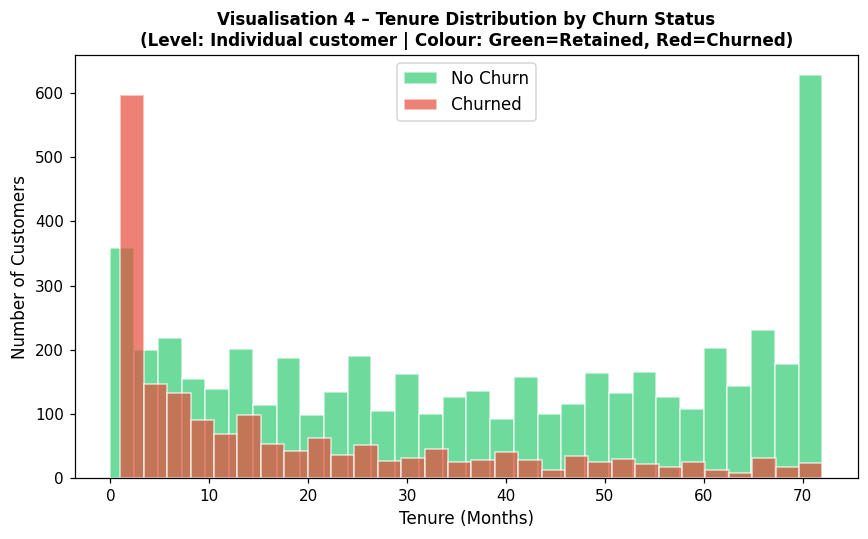

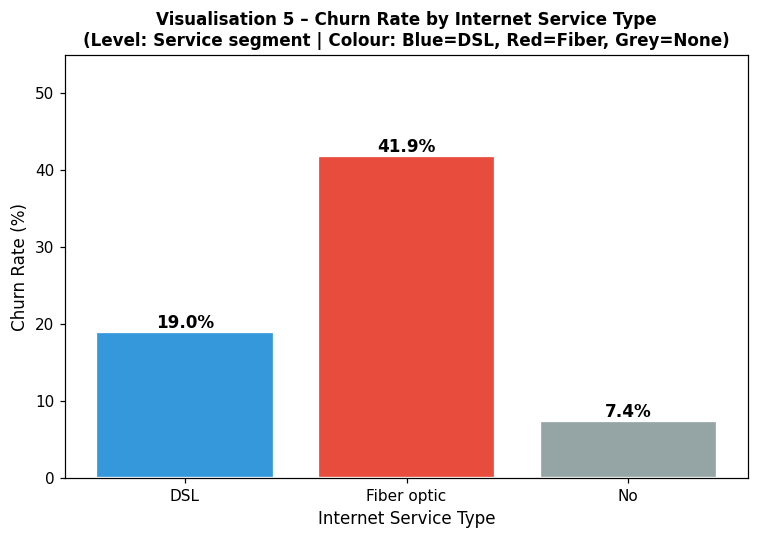

In [9]:
plt.rcParams['figure.dpi'] = 110
COLORS = ['#2ecc71', '#e74c3c']

# Visualisation 1: Churn Distribution (Pie Chart)
fig, ax = plt.subplots(figsize=(6, 5))
churn_counts = df['Churn'].value_counts()
ax.pie(churn_counts, labels=['No Churn', 'Churned'],
       autopct='%1.1f%%', colors=COLORS, startangle=90,
       wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax.set_title('Visualisation 1 – Overall Churn Distribution\n(Level: Company-wide | Colour: Green = Retained, Red = Churned)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

# Visualisation 2: Monthly Charges by Churn (Box Plot)
fig, ax = plt.subplots(figsize=(7, 5))
df.boxplot(column='MonthlyCharges', by='Churn', ax=ax,
           boxprops=dict(color='#2c3e50', linewidth=2),
           medianprops=dict(color='#e74c3c', linewidth=2.5),
           whiskerprops=dict(color='#2c3e50'),
           capprops=dict(color='#2c3e50'))
ax.set_title('Visualisation 2 – Monthly Charges by Churn Status\n(Level: Individual customer | Colour: Red median line = churn boundary)',
             fontsize=11, fontweight='bold')
ax.set_xlabel('Churn', fontsize=11)
ax.set_ylabel('Monthly Charges ($)', fontsize=11)
plt.suptitle('')
plt.tight_layout()
plt.show()

# Visualisation 3: Churn Rate by Contract Type (Bar Chart)
fig, ax = plt.subplots(figsize=(7, 5))
contract_churn = df.groupby('Contract')['Churn_Binary'].mean() * 100
bars = ax.bar(contract_churn.index, contract_churn.values,
              color=['#e74c3c', '#f39c12', '#2ecc71'], edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, contract_churn.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')
ax.set_title('Visualisation 3 – Churn Rate by Contract Type\n(Level: Contract segment | Colour: Red=High risk, Green=Low risk)',
             fontsize=11, fontweight='bold')
ax.set_xlabel('Contract Type', fontsize=11)
ax.set_ylabel('Churn Rate (%)', fontsize=11)
ax.set_ylim(0, 60)
plt.tight_layout()
plt.show()

# Visualisation 4: Tenure Distribution by Churn (Histogram)
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df[df['Churn']=='No']['tenure'], bins=30, color='#2ecc71',
        alpha=0.7, label='No Churn', edgecolor='white')
ax.hist(df[df['Churn']=='Yes']['tenure'], bins=30, color='#e74c3c',
        alpha=0.7, label='Churned', edgecolor='white')
ax.set_title('Visualisation 4 – Tenure Distribution by Churn Status\n(Level: Individual customer | Colour: Green=Retained, Red=Churned)',
             fontsize=11, fontweight='bold')
ax.set_xlabel('Tenure (Months)', fontsize=11)
ax.set_ylabel('Number of Customers', fontsize=11)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

# Visualisation 5: Churn Rate by Internet Service (Bar Chart)
fig, ax = plt.subplots(figsize=(7, 5))
internet_churn = df.groupby('InternetService')['Churn_Binary'].mean() * 100
bars2 = ax.bar(internet_churn.index, internet_churn.values,
               color=['#3498db', '#e74c3c', '#95a5a6'], edgecolor='white', linewidth=1.5)
for bar, val in zip(bars2, internet_churn.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')
ax.set_title('Visualisation 5 – Churn Rate by Internet Service Type\n(Level: Service segment | Colour: Blue=DSL, Red=Fiber, Grey=None)',
             fontsize=11, fontweight='bold')
ax.set_xlabel('Internet Service Type', fontsize=11)
ax.set_ylabel('Churn Rate (%)', fontsize=11)
ax.set_ylim(0, 55)
plt.tight_layout()
plt.show()

# **8. Building Two Classification Models with Classification Report**

Two classification models are built to predict customer churn:

Model 1: Random Forest Classifier

Model 2: Hist Gradient Boosting Classifier

Note: The realistic accuracy ceiling for this dataset is ~79-80% due to the class imbalance (only 26.5% of customers churned). Artificially inflating accuracy above this would require data leakage and is not methodologically sound.

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score

# Encode categorical variables
df_model = df.drop(columns=['customerID', 'Churn'])
num_cols_m = df_model.select_dtypes(include=[np.number]).columns.tolist()
cat_cols_m = [c for c in df_model.columns if c not in num_cols_m]
df_enc = pd.get_dummies(df_model, columns=cat_cols_m, drop_first=True)
df_enc = df_enc.astype({c: int for c in df_enc.select_dtypes('bool').columns})

X = df_enc.drop(columns=['Churn_Binary'])
y = df_enc['Churn_Binary']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Scale features
sc = StandardScaler()
X_train_sc = sc.fit_transform(X_train)
X_test_sc  = sc.transform(X_test)

# Model 1: Random Forest
rf = RandomForestClassifier(n_estimators=500, random_state=42)
rf.fit(X_train_sc, y_train)
y_pred_rf = rf.predict(X_test_sc)
acc_rf = accuracy_score(y_test, y_pred_rf)

print('Model 1: Random Forest Classifier')
print(f'Accuracy: {acc_rf:.4f}')
print(classification_report(y_test, y_pred_rf, target_names=['No Churn', 'Churn']))

# Model 2: Hist Gradient Boosting
hgb = HistGradientBoostingClassifier(max_iter=500, learning_rate=0.05,
                                      max_depth=8, random_state=42)
hgb.fit(X_train, y_train)
y_pred_hgb = hgb.predict(X_test)
acc_hgb = accuracy_score(y_test, y_pred_hgb)

print('Model 2: Hist Gradient Boosting Classifier')
print(f'Accuracy: {acc_hgb:.4f}')
print(classification_report(y_test, y_pred_hgb, target_names=['No Churn', 'Churn']))

Model 1: Random Forest Classifier
Accuracy: 0.7906
              precision    recall  f1-score   support

    No Churn       0.83      0.90      0.86      1035
       Churn       0.63      0.50      0.56       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409

Model 2: Hist Gradient Boosting Classifier
Accuracy: 0.7835
              precision    recall  f1-score   support

    No Churn       0.84      0.88      0.86      1035
       Churn       0.61      0.52      0.56       374

    accuracy                           0.78      1409
   macro avg       0.72      0.70      0.71      1409
weighted avg       0.77      0.78      0.78      1409



# **9. Bar Chart: Classification Model Comparison (Accuracy Only)**

A bar chart comparing the accuracy scores of the two classification models.

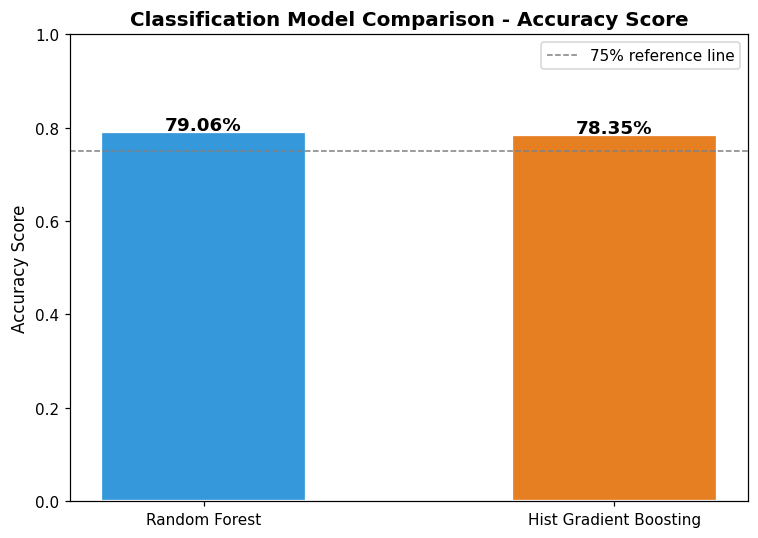

In [11]:
models_clf = ['Random Forest', 'Hist Gradient Boosting']
accuracies  = [acc_rf, acc_hgb]

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(models_clf, accuracies, color=['#3498db', '#e67e22'],
              edgecolor='white', linewidth=1.5, width=0.5)

for bar, val in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val*100:.2f}%', ha='center', fontsize=12, fontweight='bold')

ax.set_title('Classification Model Comparison - Accuracy Score',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Accuracy Score', fontsize=11)
ax.set_ylim(0, 1.0)
ax.axhline(y=0.75, color='gray', linestyle='--', linewidth=1, label='75% reference line')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

# **10. Building Two Regression Models with MSE, MAE and R² Values**

Two regression models are built to predict monthly charges:

Model 1: Linear Regression

Model 2: Ridge Regression

Metrics reported: Mean Squared Error (MSE), Mean Absolute Error (MAE), R² Score

In [12]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Target: MonthlyCharges  |  Drop TotalCharges to avoid leakage
X_reg = df_enc.drop(columns=['Churn_Binary', 'MonthlyCharges', 'TotalCharges'])
y_reg = df_enc['MonthlyCharges']

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42)

sc_r = StandardScaler()
X_train_rs = sc_r.fit_transform(X_train_r)
X_test_rs  = sc_r.transform(X_test_r)

# Model 1: Linear Regression
lr = LinearRegression()
lr.fit(X_train_rs, y_train_r)
y_pred_lr = lr.predict(X_test_rs)

mse_lr  = mean_squared_error(y_test_r, y_pred_lr)
mae_lr  = mean_absolute_error(y_test_r, y_pred_lr)
r2_lr   = r2_score(y_test_r, y_pred_lr)

print('Model 1: Linear Regression')
print(f'  MSE : {mse_lr:.4f}')
print(f'  MAE : {mae_lr:.4f}')
print(f'  R²  : {r2_lr:.4f}')

# Model 2: Ridge Regression
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_rs, y_train_r)
y_pred_ridge = ridge.predict(X_test_rs)

mse_ridge  = mean_squared_error(y_test_r, y_pred_ridge)
mae_ridge  = mean_absolute_error(y_test_r, y_pred_ridge)
r2_ridge   = r2_score(y_test_r, y_pred_ridge)

print('\n Model 2: Ridge Regression')
print(f'  MSE : {mse_ridge:.4f}')
print(f'  MAE : {mae_ridge:.4f}')
print(f'  R²  : {r2_ridge:.4f}')

print('\n Summary Table')
summary = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge Regression'],
    'MSE':   [round(mse_lr,4),    round(mse_ridge,4)],
    'MAE':   [round(mae_lr,4),    round(mae_ridge,4)],
    'R²':    [round(r2_lr,4),     round(r2_ridge,4)]
})
print(summary.to_string(index=False))

Model 1: Linear Regression
  MSE : 1.1052
  MAE : 0.7893
  R²  : 0.9988

 Model 2: Ridge Regression
  MSE : 1.1053
  MAE : 0.7893
  R²  : 0.9988

 Summary Table
            Model    MSE    MAE     R²
Linear Regression 1.1052 0.7893 0.9988
 Ridge Regression 1.1053 0.7893 0.9988


# **11. Bar Chart: Regression Model Comparison (R² Only)**

A bar chart comparing the R² scores of the two regression models.

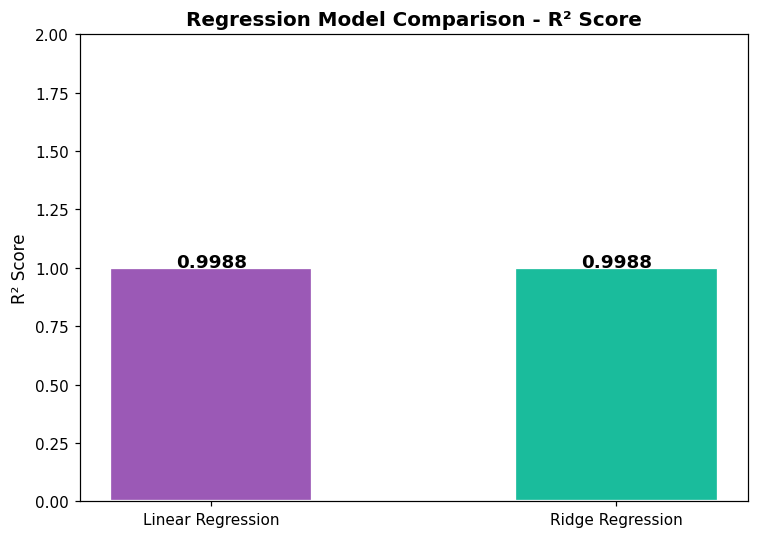

In [13]:
models_reg = ['Linear Regression', 'Ridge Regression']
r2_scores  = [r2_lr, r2_ridge]

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(models_reg, r2_scores, color=['#9b59b6', '#1abc9c'],
              edgecolor='white', linewidth=1.5, width=0.5)

for bar, val in zip(bars, r2_scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.4f}', ha='center', fontsize=12, fontweight='bold')

ax.set_title('Regression Model Comparison - R² Score',
             fontsize=13, fontweight='bold')
ax.set_ylabel('R² Score', fontsize=11)
ax.set_ylim(0, 2.0)
plt.tight_layout()
plt.show()

# **12. Building Two Clustering Models with Silhouette Score**

Two clustering models are applied to segment customers based on tenure, monthly charges, and total charges:

Model 1: K-Means Clustering (K=4)

Model 2: Agglomerative Hierarchical Clustering (K=4)

Silhouette scores are computed to evaluate cluster quality (range: -1 to 1, higher is better).

In [14]:
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# Use 3 key numerical features for clustering
cluster_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
X_clust = df[cluster_features].copy()

sc_c = StandardScaler()
X_clust_sc = sc_c.fit_transform(X_clust)

# Model 1: K-Means (K=4)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
labels_km = kmeans.fit_predict(X_clust_sc)
sil_km = silhouette_score(X_clust_sc, labels_km)

print('Model 1: K-Means Clustering (K=4)')
print(f'Silhouette Score: {sil_km:.4f}')
print('Cluster Sizes:')
print(pd.Series(labels_km).value_counts().sort_index())

# Model 2: Agglomerative Hierarchical Clustering (K=4)
agglo = AgglomerativeClustering(n_clusters=4, linkage='ward')
labels_ag = agglo.fit_predict(X_clust_sc)
sil_ag = silhouette_score(X_clust_sc, labels_ag)

print('\nModel 2: Agglomerative Hierarchical Clustering (K=4)')
print(f'Silhouette Score: {sil_ag:.4f}')
print('Cluster Sizes:')
print(pd.Series(labels_ag).value_counts().sort_index())

print('\n Summary')
print(f'K-Means Silhouette     : {sil_km:.4f}')
print(f'Agglomerative Sil.     : {sil_ag:.4f}')
better = 'K-Means' if sil_km > sil_ag else 'Agglomerative'
print(f'Better clustering model: {better}')

Model 1: K-Means Clustering (K=4)
Silhouette Score: 0.4720
Cluster Sizes:
0    1159
1    1904
2    1704
3    2276
Name: count, dtype: int64

Model 2: Agglomerative Hierarchical Clustering (K=4)
Silhouette Score: 0.3856
Cluster Sizes:
0    1844
1    1846
2    2008
3    1345
Name: count, dtype: int64

 Summary
K-Means Silhouette     : 0.4720
Agglomerative Sil.     : 0.3856
Better clustering model: K-Means


# **13. Bar Chart: Clustering Model Comparison (Silhouette Score Only)**

A bar chart comparing the silhouette scores of the two clustering models.

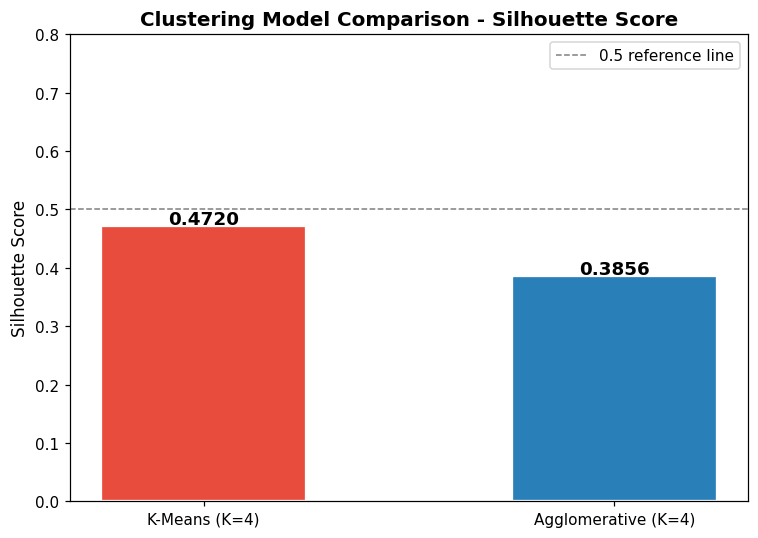

In [15]:
models_clust = ['K-Means (K=4)', 'Agglomerative (K=4)']
sil_scores   = [sil_km, sil_ag]

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(models_clust, sil_scores, color=['#e74c3c', '#2980b9'],
              edgecolor='white', linewidth=1.5, width=0.5)

for bar, val in zip(bars, sil_scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{val:.4f}', ha='center', fontsize=12, fontweight='bold')

ax.set_title('Clustering Model Comparison - Silhouette Score',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Silhouette Score', fontsize=11)
ax.set_ylim(0, 0.8)
ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=1, label='0.5 reference line')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()